In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
dsf_data1 = pd.read_csv("data/2025-08-15_FlA_ZP_CKW_20250815_145006_AnalysisResults_wellresults_edited.txt", sep="\t")
dsf_data2 = pd.read_csv("data/2025112025_FlA_ZS_top_20251125_141248_AnalysisResults.txt", sep="\t")
pd.set_option('display.max_columns', None)

In [3]:
plotdata = pd.melt(dsf_data1, id_vars=["Protein", "Ligand"], value_vars=["Tm B"])
plotdata = plotdata.groupby(by=["Protein", "Ligand"])["value"].agg(["mean", "std"]).reset_index()

In [4]:
plotdata2 = pd.melt(dsf_data2, id_vars=["Protein"], value_vars=["Tm B"])
plotdata2 = plotdata2.groupby(by=["Protein"])["value"].agg(["mean", "std"]).reset_index()
plotdata2['Type'] = plotdata2['Protein'].apply(lambda x: 'Buffer' if x.count('+') == 0 else 'SAM')
plotdata2["Protein"] = plotdata2["Protein"].str.replace(' + SAM', '', regex=False)
plotdata2

,Protein,mean,std,Type
0,G37D,56.208404,0.644935,Buffer
1,G37D,57.382385,0.223678,SAM
2,H191E,58.578929,0.244942,Buffer
3,H191E,59.105013,0.460135,SAM
4,H32L,58.465320,0.442329,Buffer
5,H32L,59.198248,0.468407,SAM
6,K237R,58.661395,0.413851,Buffer
7,K237R,60.477515,0.203928,SAM
8,S166A,56.066226,0.305490,Buffer
9,S166A,57.663500,0.487439,SAM


In [5]:
rxn_data = plotdata[plotdata['Ligand'] == 'rxn']
rxn_data['Protein'] = rxn_data['Protein'].str.replace('FlA_', '', regex=False)
rxn_data.drop(index=14, inplace=True)  # drop FlA_Quad
rxn_data['Type'] = ['F-']*6
rxn_data.drop(columns=['Ligand'], inplace=True)
rxn_data.reset_index(drop=True, inplace=True)
rxn_data

C:\Users\dhard\AppData\Local\Temp\ipykernel_2828\2145490750.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rxn_data['Protein'] = rxn_data['Protein'].str.replace('FlA_', '', regex=False)
C:\Users\dhard\AppData\Local\Temp\ipykernel_2828\2145490750.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rxn_data.drop(index=14, inplace=True)  # drop FlA_Quad
C:\Users\dhard\AppData\Local\Temp\ipykernel_2828\2145490750.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

,Protein,mean,std,Type
0,G37D,56.926460,0.359255,F-
1,H191E,58.208665,0.519146,F-
2,H32L,59.152051,0.277423,F-
3,K237R,58.998820,0.022205,F-
4,S166A,55.807317,0.215301,F-
5,WT,56.789372,0.083800,F-


In [6]:
# Combine data for plotting
combined_data = pd.concat([rxn_data, plotdata2], ignore_index=True)
combined_data.sort_values(["Protein", "Type"])
combined_data

,Protein,mean,std,Type
0,G37D,56.926460,0.359255,F-
1,H191E,58.208665,0.519146,F-
2,H32L,59.152051,0.277423,F-
3,K237R,58.998820,0.022205,F-
4,S166A,55.807317,0.215301,F-
5,WT,56.789372,0.083800,F-
6,G37D,56.208404,0.644935,Buffer
7,G37D,57.382385,0.223678,SAM
8,H191E,58.578929,0.244942,Buffer
9,H191E,59.105013,0.460135,SAM


In [7]:
lig_dict = {
    'Buffer': 'Reaction Buffer',
    'SAM': 'Reaction Buffer + SAM',
    'F-': 'Reaction Buffer + F-'
}

In [8]:
relative_data = combined_data.copy()
wt_buffer_tm = combined_data[(combined_data['Protein'] == 'WT') & (combined_data['Type'] == 'Buffer')]['mean'].values[0]
wt_sam_tm = combined_data[(combined_data['Protein'] == 'WT') & (combined_data['Type'] == 'SAM')]['mean'].values[0]
wt_f_tm = combined_data[(combined_data['Protein'] == 'WT') & (combined_data['Type'] == 'F-')]['mean'].values[0]

wt_buffer_std = combined_data[(combined_data['Protein'] == 'WT') & (combined_data['Type'] == 'Buffer')]['std'].values[0]
wt_sam_std = combined_data[(combined_data['Protein'] == 'WT') & (combined_data['Type'] == 'SAM')]['std'].values[0]
wt_f_std = combined_data[(combined_data['Protein'] == 'WT') & (combined_data['Type'] == 'F-')]['std'].values[0]

relative_data['mean'] = relative_data.apply(
    lambda row: row['mean'] - (wt_buffer_tm if row['Type'] == 'Buffer' else (wt_sam_tm if row['Type'] == 'SAM' else wt_f_tm)), axis=1
)

relative_data['std'] = relative_data.apply(
    lambda row: np.sqrt(row['std']**2 + (wt_buffer_std**2 if row['Type'] == 'Buffer' else (wt_sam_std**2 if row['Type'] == 'SAM' else wt_f_std**2))), axis=1
)

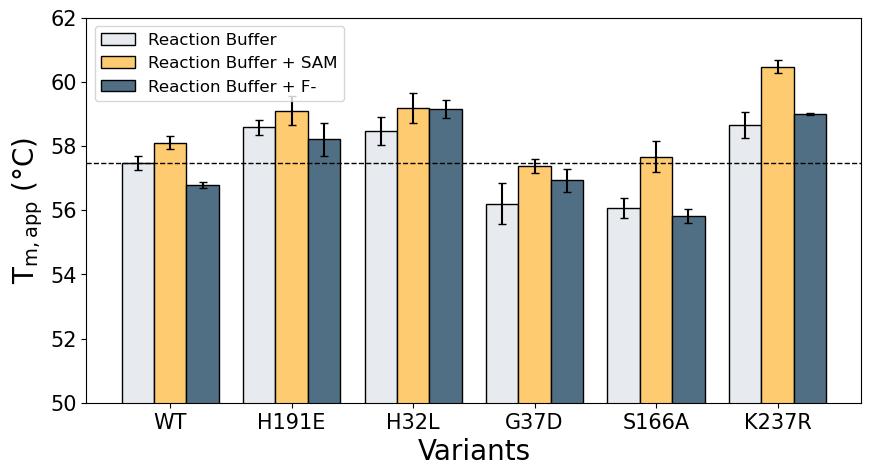

In [16]:
# Order proteins
protein_order = ["WT", "H191E", "H32L", "G37D", "S166A", "K237R"]
combined_data = combined_data.sort_values(["Protein", "Type"])

#color_map = dict(zip(lig_dict.keys(), ["#DF9966", '#FFEFD3', "#516F84"][:len(lig_dict)]))
color_map = dict(zip(lig_dict.keys(), ["#E7EAEE", '#FFCB70', "#516F84"][:len(lig_dict)]))

# Pivot for consistent alignment (rows: proteins, cols: ligands)
mean_piv = combined_data.pivot(index="Protein", columns="Type", values="mean").reindex(protein_order)
std_piv  = combined_data.pivot(index="Protein", columns="Type", values="std").reindex(protein_order)

# X positions and grouped bar offsets
x = np.arange(len(protein_order))
nL = len(lig_dict)
total_width = 0.8
bar_w = total_width / max(nL, 1)
offsets = (np.arange(nL) - (nL - 1) / 2.0) * bar_w

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

for i, lig in enumerate(lig_dict.keys()):
    y    = mean_piv[lig].to_numpy()
    yerr = std_piv[lig].to_numpy()
    # Handle missing combos gracefully
    y_plot    = np.nan_to_num(y, nan=0.0)
    yerr_plot = np.nan_to_num(yerr, nan=0.0)

    ax.bar(
        x + offsets[i],
        y_plot,
        width=bar_w,
        yerr=yerr_plot,
        label=lig_dict.get(lig, lig),
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=color_map.get(lig, None),
    )

# Reference line and limits
wt_buffer_tm = combined_data[(combined_data['Protein'] == 'WT') & (combined_data['Type'] == 'Buffer')]['mean'].values[0]
ax.axhline(wt_buffer_tm, linestyle="--", linewidth=1.0, color="black")
ax.set_ylim(50, 60)

# Labels, ticks, legend
ax.set_xlabel("Variants",fontsize=20)
ax.set_ylabel(r"T$_{\mathrm{m,app}}$ (°C)",fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(["WT", "H191E", "H32L", "G37D", "S166A", "K237R"], rotation=0, ha="center")
ax.legend(fontsize=12)

ax.set_ylim(50,62)

ax.tick_params(axis='both', which='major', labelsize=15)

#plt.tight_layout()
plt.show()



In [10]:
combined_data.to_csv("data/Tm_combined_data.csv", index=False)

In [11]:
mean_piv

Type,Buffer,F-,SAM
Protein,,,
WT,57.479644,56.789372,58.103885
H191E,58.578929,58.208665,59.105013
H32L,58.465320,59.152051,59.198248
G37D,56.208404,56.926460,57.382385
S166A,56.066226,55.807317,57.663500
K237R,58.661395,58.998820,60.477515


In [12]:
std_piv

Type,Buffer,F-,SAM
Protein,,,
WT,0.214209,0.083800,0.204604
H191E,0.244942,0.519146,0.460135
H32L,0.442329,0.277423,0.468407
G37D,0.644935,0.359255,0.223678
S166A,0.305490,0.215301,0.487439
K237R,0.413851,0.022205,0.203928


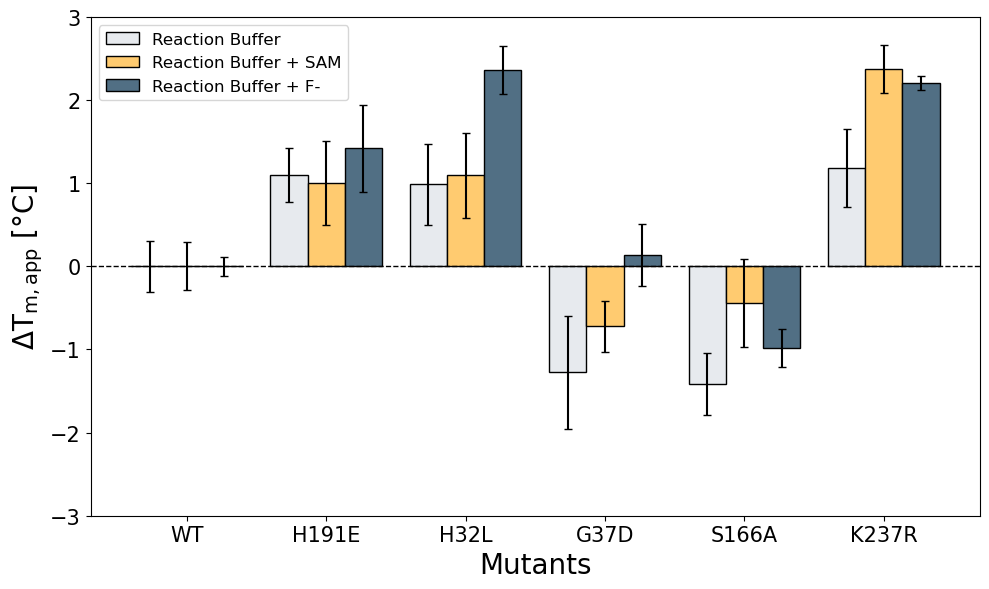

In [13]:
# Order proteins
protein_order = ["WT", "H191E", "H32L", "G37D", "S166A", "K237R"]
relative_data = relative_data.sort_values(["Protein", "Type"])

#color_map = dict(zip(lig_dict.keys(), ["#DF9966", '#FFEFD3', "#516F84"][:len(lig_dict)]))
color_map = dict(zip(lig_dict.keys(), ["#E7EAEE", '#FFCB70', "#516F84"][:len(lig_dict)]))

# Pivot for consistent alignment (rows: proteins, cols: ligands)
mean_piv = relative_data.pivot(index="Protein", columns="Type", values="mean").reindex(protein_order)
std_piv  = relative_data.pivot(index="Protein", columns="Type", values="std").reindex(protein_order)

# X positions and grouped bar offsets
x = np.arange(len(protein_order))
nL = len(lig_dict)
total_width = 0.8
bar_w = total_width / max(nL, 1)
offsets = (np.arange(nL) - (nL - 1) / 2.0) * bar_w

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for i, lig in enumerate(lig_dict.keys()):
    y    = mean_piv[lig].to_numpy()
    yerr = std_piv[lig].to_numpy()
    # Handle missing combos gracefully
    y_plot    = np.nan_to_num(y, nan=0.0)
    yerr_plot = np.nan_to_num(yerr, nan=0.0)

    ax.bar(
        x + offsets[i],
        y_plot,
        width=bar_w,
        yerr=yerr_plot,
        label=lig_dict.get(lig, lig),
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=color_map.get(lig, None),
    )

# Reference line and limits
ax.axhline(0, linestyle="--", linewidth=1.0, color="black")
ax.set_ylim(-3, 3)

# Labels, ticks, legend
ax.set_xlabel("Mutants",fontsize=20)
ax.set_ylabel(r"$\Delta$T$_{\mathrm{m,app}}$ [°C]",fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(["WT", "H191E", "H32L", "G37D", "S166A", "K237R"], rotation=0, ha="center")
ax.legend(fontsize=12)


ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

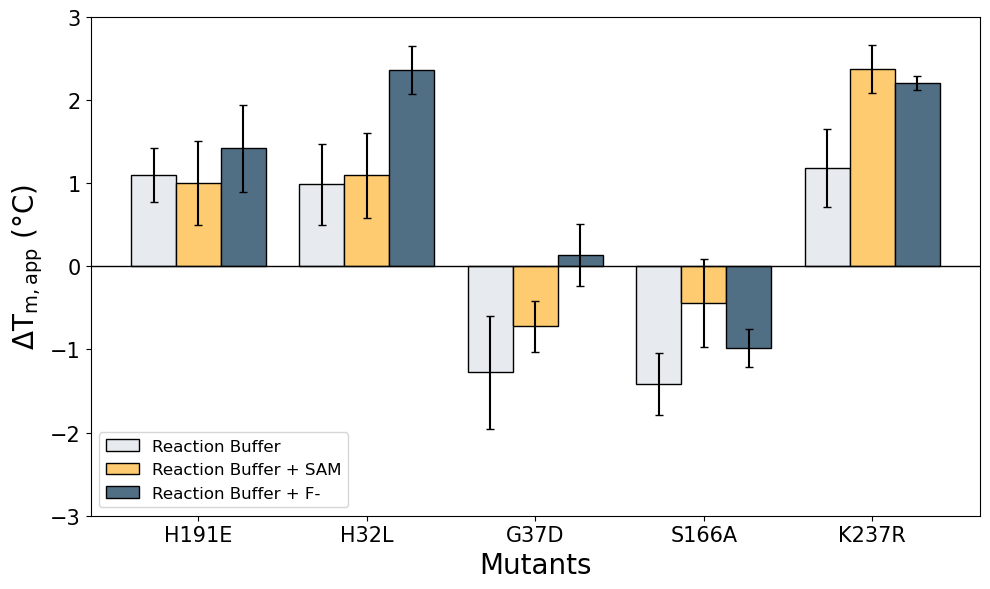

In [15]:
# Order proteins
protein_order = ["H191E", "H32L", "G37D", "S166A", "K237R"]
relative_data = relative_data.sort_values(["Protein", "Type"])

#color_map = dict(zip(lig_dict.keys(), ["#DF9966", '#FFEFD3', "#516F84"][:len(lig_dict)]))
color_map = dict(zip(lig_dict.keys(), ["#E7EAEE", '#FFCB70', "#516F84"][:len(lig_dict)]))

# Pivot for consistent alignment (rows: proteins, cols: ligands)
mean_piv = relative_data.pivot(index="Protein", columns="Type", values="mean").reindex(protein_order)
std_piv  = relative_data.pivot(index="Protein", columns="Type", values="std").reindex(protein_order)

# X positions and grouped bar offsets
x = np.arange(len(protein_order))
nL = len(lig_dict)
total_width = 0.8
bar_w = total_width / max(nL, 1)
offsets = (np.arange(nL) - (nL - 1) / 2.0) * bar_w

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for i, lig in enumerate(lig_dict.keys()):
    y    = mean_piv[lig].to_numpy()
    yerr = std_piv[lig].to_numpy()
    # Handle missing combos gracefully
    y_plot    = np.nan_to_num(y, nan=0.0)
    yerr_plot = np.nan_to_num(yerr, nan=0.0)

    ax.bar(
        x + offsets[i],
        y_plot,
        width=bar_w,
        yerr=yerr_plot,
        label=lig_dict.get(lig, lig),
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=color_map.get(lig, None),
    )

# Reference line and limits
ax.axhline(0, linestyle="-", linewidth=1.0, color="black")
ax.set_ylim(-3, 3)

# Labels, ticks, legend
ax.set_xlabel("Mutants",fontsize=20)
ax.set_ylabel(r"$\Delta$T$_{\mathrm{m,app}}$ (°C)",fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(["H191E", "H32L", "G37D", "S166A", "K237R"], rotation=0, ha="center")
ax.legend(fontsize=12)


ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()